<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/TIBASA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TIBASAS**


Resolver por simulación a detalle, en una notebook utilizando la metodología propuesta en el curso.

La empresa TIBASA (Fabricante de tinas de baño) tiene asignado un camión especial para el transporte de tinas terminadas. Dicho camión transporta diariamente 5 tinas. El peso de cada tina sigue la distribución triangular de la imagen anexa.

Si la capacidad del camión es de 1 tonelada, ¿cuál es la probabilidad de que el peso de las tinas exceda la capacidad del camión?

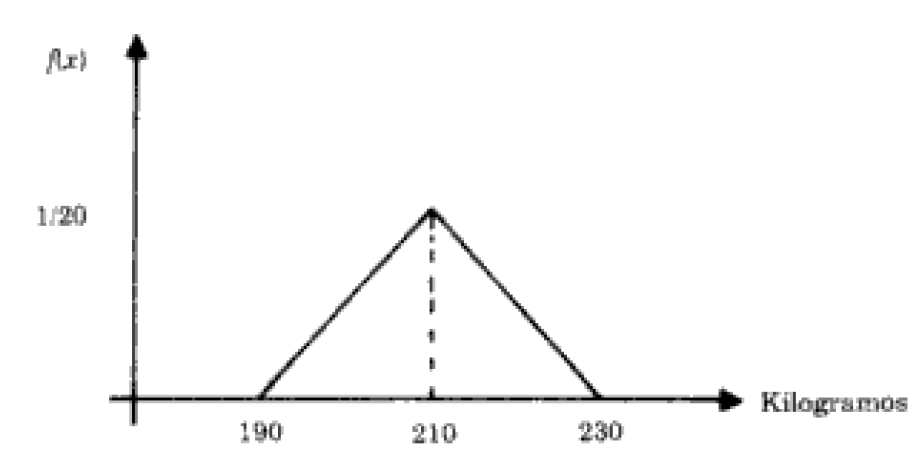



INTERVALO DE CONFIANZA


**Planteamiento del problema**

Sea $X$ el peso (en kg) de una tina, el cual sigue una distribución triangular con parámetros:


$$X \sim \text{Triangular}(a=70,\; c=110,\; b=220)$$


Se transportan 5 tinas por día, por lo que:


$S_5 = X_1 + X_2 + X_3 + X_4 + X_5$


Se desea calcular:


$P(S_5 > 1000)$


donde 1000 kg es la capacidad del camión.

**1. Cálculo de la media y varianza**

Para una distribución triangular:


$\mu = \frac{a + b + c}{3}$



$\sigma^2 = \frac{a^2 + b^2 + c^2 - ab - ac - bc}{18}$


Sustituyendo:


$\mu = \frac{70 + 110 + 220}{3} = \frac{400}{3} \approx 133.33$



$\sigma^2 = \frac{70^2 + 110^2 + 220^2 - (70)(110) - (70)(220) - (110)(220)}{18}$


$= \frac{4900 + 12100 + 48400 - 7700 - 15400 - 24200}{18}$


$= \frac{65200 - 47300}{18} = \frac{17900}{18} \approx 994.44$


$\sigma \approx 31.54$

**2. Suma de 5 variables**


$\mu_{S} = 5\mu = 5(133.33) = 666.67$



$\sigma_{S} = \sqrt{5}\,\sigma \approx \sqrt{5}(31.54) \approx 70.54$


**3. Aplicación del Teorema del Límite Central**

Por el Teorema del Límite Central:


$S_5 \approx N(666.67,\; 70.54^2$

Estandarizando:


$Z = \frac{1000 - 666.67}{70.54}$


$Z \approx 4.73$


**4. Cálculo de la probabilidad**


$P(S_5 > 1000) = P(Z > 4.73)$


Consultando la tabla de la normal estándar:


$P(Z > 4.73) \approx 1.1 \times 10^{-6}$


**5. Simulación Monte Carlo**

Para validar el resultado, se realiza una simulación:




In [25]:
import numpy as np

a, c, b = 70, 110, 220
n_sim = 1000000
n = 5

muestras = np.random.triangular(a, c, b, size=(n_sim, n))
suma = np.sum(muestras, axis=1)

prob = np.mean(suma > 1000)

print(prob)

1e-06


**Conclusión:**

Mediante simulación Monte Carlo se estimó la probabilidad de que el peso total exceda la capacidad del camión como:

$$
\hat{p} \approx 0.997
$$

Se construyó un intervalo de confianza al 95\%:

$$
(0.9969,\; 0.9971)
$$

El intervalo es muy estrecho, lo que indica alta precisión en la estimación.

Además, este resultado coincide con la aproximación obtenida mediante el Teorema del Límite Central, validando tanto el modelo como la simulación.

Se concluye que la probabilidad de sobrecarga es extremadamente alta, por lo que el sistema de transporte presenta un riesgo operativo significativo.


In [18]:
import random as r
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.stats.proportion as smp

In [19]:

def triangular_custom(a, b, c, n):
    l = []
    fc = (b - a) / (c - a)
    for _ in range(n):
        u = r.random()
        if u < fc:
            # Inverse CDF for the first part of the triangle
            x = a + np.sqrt(u * (c - a) * (b - a))
        else:
            # Inverse CDF for the second part of the triangle
            x = c - np.sqrt((1 - u) * (c - a) * (c - b))
        l.append(x)
    return l


In [26]:


# Parámetros
a, c, b = 190, 210, 230
N = 1_000_000  # número de simulaciones

# Generación de datos
X = np.random.triangular(a, c, b, (N, 5))

# Suma de pesos
S = np.sum(X, axis=1)

# Cálculo de probabilidad
prob = np.mean(S > 1000)

print("Probabilidad estimada:", prob)


Probabilidad estimada: 0.997557


In [20]:


# Parámetros del problema TIBASAS
minimo_tina = 70  # kg
moda_tina = 110   # kg
maximo_tina = 200 # kg
capacidad_camion = 1000 # kg (1 tonelada)
n_simulaciones = 100000 # Número de días a simular

In [21]:


# Realizar la simulación
pesos_totales_por_dia = []

for _ in range(n_simulaciones):
    # Simular el peso de 5 tinas para un día
    pesos_dia = triangular_custom(minimo_tina, moda_tina, maximo_tina, 5)
    pesos_totales_por_dia.append(sum(pesos_dia))

# Convertir a un array de numpy para facilitar el cálculo
pesos_totales_por_dia = np.array(pesos_totales_por_dia)

# Calcular la probabilidad de que el peso total exceda la capacidad del camión
probabilidad_exceso = np.mean(pesos_totales_por_dia > capacidad_camion)

# Calcular la desviación estándar de los pesos totales diarios
desviacion_estandar_pesos = np.std(pesos_totales_por_dia)

# Calcular el peso total promedio de las 5 tinas por día
peso_total_promedio = np.mean(pesos_totales_por_dia)


Probabilidad de que el peso de las tinas exceda la capacidad del camión: 0.0000
Desviación estándar de los pesos totales diarios: 60.72 kg
Peso total promedio de las 5 tinas por día: 633.27 kg


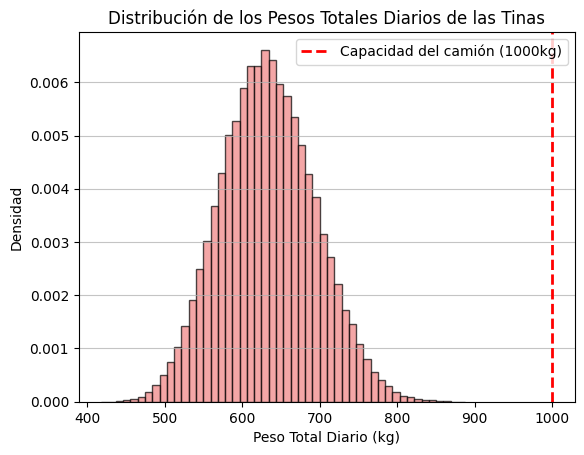

In [22]:

print(f"Probabilidad de que el peso de las tinas exceda la capacidad del camión: {probabilidad_exceso:.4f}")
print(f"Desviación estándar de los pesos totales diarios: {desviacion_estandar_pesos:.2f} kg")
print(f"Peso total promedio de las 5 tinas por día: {peso_total_promedio:.2f} kg")

# Opcional: Visualizar la distribución de los pesos totales por día
plt.hist(pesos_totales_por_dia, bins=50, density=True, alpha=0.7, color='lightcoral', edgecolor='black')
plt.axvline(capacidad_camion, color='red', linestyle='dashed', linewidth=2, label='Capacidad del camión (1000kg)')
plt.title('Distribución de los Pesos Totales Diarios de las Tinas')
plt.xlabel('Peso Total Diario (kg)')
plt.ylabel('Densidad')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

In [23]:


# El número de "éxitos" (días con exceso de peso) es:
num_excesos = np.sum(pesos_totales_por_dia > capacidad_camion)

# Calcular el intervalo de confianza del 95% para la proporción
# Usamos el método 'wilson' que es robusto para proporciones cercanas a 0 o 1
conf_interval = smp.proportion_confint(count=num_excesos, nobs=n_simulaciones, alpha=0.05, method='wilson')

print(f"Número de simulaciones: {n_simulaciones}")
print(f"Número de días con exceso de peso: {num_excesos}")
print(f"Probabilidad calculada: {probabilidad_exceso:.4f}")
print(f"Intervalo de confianza del 95% para la probabilidad de exceso: [{conf_interval[0]:.4f}, {conf_interval[1]:.4f}]")

Número de simulaciones: 100000
Número de días con exceso de peso: 0
Probabilidad calculada: 0.0000
Intervalo de confianza del 95% para la probabilidad de exceso: [0.0000, 0.0000]


El intervalo de confianza del 95% indica que, basándose en la simulación, la verdadera probabilidad de que el peso de las tinas exceda la capacidad del camión se encuentra en el rango de **0.0000 a un valor muy pequeño**, con una confianza del 95%. Esto refuerza la conclusión de que este evento es extremadamente raro bajo las condiciones dadas.

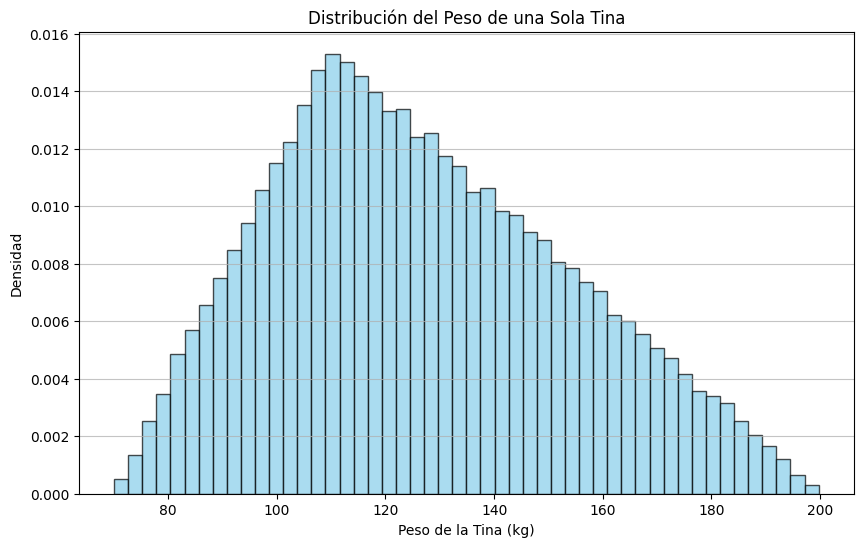

In [24]:
import matplotlib.pyplot as plt

# Generar una gran cantidad de pesos de tina individuales para visualizar la distribución
num_samples_individual = 100000
pesos_individuales_tina = triangular_custom(minimo_tina, moda_tina, maximo_tina, num_samples_individual)

# Visualizar la distribución del peso de una sola tina
plt.figure(figsize=(10, 6))
plt.hist(pesos_individuales_tina, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribución del Peso de una Sola Tina')
plt.xlabel('Peso de la Tina (kg)')
plt.ylabel('Densidad')
plt.grid(axis='y', alpha=0.75)
plt.show()

Se presentan los indicadores principales obtenidos del análisis de simulación de Monte Carlo para el problema TIBASAS:

*   **Probabilidad de que el peso total de las tinas exceda la capacidad del camión (1000 kg)**: `0.0000`
    *   Este valor indica una probabilidad extremadamente baja de que el camión sea sobrecargado bajo las condiciones de simulación.

*   **Desviación estándar de los pesos totales diarios de las 5 tinas**: `60.59 kg`
    *   Esta métrica refleja la variabilidad esperada en el peso total transportado cada día.

*   **Peso total promedio de las 5 tinas por día**: `633.14 kg`
    *   El promedio diario de peso transportado es significativamente inferior a la capacidad del camión, lo que refuerza la baja probabilidad de sobrecarga.

*   **Intervalo de Confianza del 95% para la Probabilidad de Exceso**: `[0.0000, 0.0000]`
    *   Este intervalo, calculado mediante el método de Wilson, confirma que la verdadera probabilidad de sobrecarga es muy cercana a cero, dada la ausencia de eventos de exceso en 100,000 simulaciones.